# LSTM — Wind Speed Forecasting
## Variable Set 1

In [5]:
# =============================================================================
# INSTALLING PACKAGES
# =============================================================================
# !pip install statsmodels optuna tabulate gdown scikeras tensorflow scikit-learn

IndentationError: unexpected indent (2935303451.py, line 4)

In [15]:
!pip install -U scikit-learn scikeras

!pip install scikeras

import sklearn
import scikeras

print("scikit-learn version:", sklearn.__version__)
print("scikeras version:", scikeras.__version__)
#scikit-learn >= 1.2.0
#scikeras >= 0.10.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 49.0 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1


Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/base_command.py", line 179, in exc_logging_wrapper
    status = run_func(*args)
             ^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/req_command.py", line 67, in wrapper
^C
scikit-learn version: 1.6.1
scikeras version: 0.13.0


In [1]:
!pip install optuna

In [2]:
# =============================================================================
# IMPORTS
# =============================================================================

# Standard libraries
import os
import sys
import random
import warnings
warnings.filterwarnings("ignore")

# Data manipulation
import numpy as np
import pandas as pd
from collections import Counter

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from matplotlib.colors import ListedColormap

# Scikit-learn: preprocessing & model selection
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler
from sklearn import model_selection, metrics, preprocessing
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV,
    RandomizedSearchCV,
    TimeSeriesSplit
)
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LinearRegression
from sklearn.inspection import permutation_importance
from scipy.stats import randint, uniform, pointbiserialr, chi2_contingency, spearmanr, entropy

# Statistical analysis
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.graphics.gofplots import qqplot

# Tabulate
from tabulate import tabulate

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# SciKeras wrapper (for sklearn-compatible LSTM)
from scikeras.wrappers import KerasRegressor

# Optuna
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)  # Suppress Optuna trial logs

# Google Drive download
import gdown

# Global random seed
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

# Set visualization style
#sns.set()  # Set Seaborn default style
#plt.style.use('ggplot')  # Set ggplot style for matplotlib

In [3]:
# =============================================================================
# LOADING THE DATA SET
# =============================================================================
# Dataset source:
# https://drive.google.com/file/d/1Z_KsoIumw-fvivVombIoWuRo0LOe2nCb/view?usp=sharing
# https://drive.google.com/file/d/1aD1PXfwEEZ_F2lQgxuPfj-TVbxQ6NajK/view?usp=sharing

file_id      = "1qhCB1Dod6jeEsuKy5sNk4MNHSjtENSrx"
download_url = f"https://drive.google.com/uc?id={file_id}"

# Read the data
df = pd.read_csv(download_url)

# Backup original DataFrame
df_backup = df.copy()

In [4]:
# =============================================================================
# DATA PREPROCESSING
# =============================================================================

# Create datetime directly from differently named columns
df['Date'] = pd.to_datetime({
    'year': df['YEAR'],
    'month': df['MO'],
    'day': df['DY']
})

# Set Date as the index
df = df.set_index('Date')

# Drop unnecessary columns
df = df.drop(columns=["YEAR", "MO", "DY"])

# Display the DataFrame (optional in scripts)
print(df.head())
print("\nColumns:", df.columns.tolist())

            WS10M_lag1   PREC     RH  MIN_TEMP  MAX_TEMP    WD_sin  \
Date                                                                 
2013-01-03        4.25  13.42  86.26     23.42     28.38  0.439939   
2013-01-04        4.75   8.79  86.31     22.93     27.58  0.424199   
2013-01-05        5.74   2.60  86.88     22.17     26.16  0.563526   
2013-01-06        5.79   1.65  88.09     23.47     27.75  0.460200   
2013-01-07        4.52  27.41  93.04     24.04     26.70  0.368125   

            SURF_PRESSSURE    WD_cos  AVG_TEMP  WS10M_lag2  PREC_lag1  \
Date                                                                    
2013-01-03           99.68  0.898028      26.4        3.99       1.09   
2013-01-04           99.65  0.905569      25.1        4.25      13.42   
2013-01-05           99.50  0.826098      26.9        4.75       8.79   
2013-01-06           99.47  0.887815      27.3        5.74       2.60   
2013-01-07           99.46  0.929776      25.9        5.79       1.65  

In [5]:
# =============================================================================
# TRAIN / TEST SPLIT  (80% train — 20% test, temporal order preserved)
# =============================================================================
## Data Sets

# Define features and target
X = df.drop(columns=['WS10M'])   # Features (lagged variables)
y = df['WS10M']                  # Target variable (wind speed)

numerical_cols = df.columns

# Define the split index — 80% for training, 20% for testing
split_index = int(len(X) * 0.8)

# Training set
X_train = X.iloc[:split_index]
y_train = y.iloc[:split_index]

# Testing set
X_test = X.iloc[split_index:]
y_test = y.iloc[split_index:]

print("X_train:\n", X_train.head())
print("y_train:\n", y_train.head())
print("X_test:\n",  X_test.head())
print("y_test:\n",  y_test.head())

print("\nShapes:")
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape: ", X_test.shape)
print("y_test shape: ", y_test.shape)

X_train:
             WS10M_lag1   PREC     RH  MIN_TEMP  MAX_TEMP    WD_sin  \
Date                                                                 
2013-01-03        4.25  13.42  86.26     23.42     28.38  0.439939   
2013-01-04        4.75   8.79  86.31     22.93     27.58  0.424199   
2013-01-05        5.74   2.60  86.88     22.17     26.16  0.563526   
2013-01-06        5.79   1.65  88.09     23.47     27.75  0.460200   
2013-01-07        4.52  27.41  93.04     24.04     26.70  0.368125   

            SURF_PRESSSURE    WD_cos  AVG_TEMP  WS10M_lag2  PREC_lag1  \
Date                                                                    
2013-01-03           99.68  0.898028      26.4        3.99       1.09   
2013-01-04           99.65  0.905569      25.1        4.25      13.42   
2013-01-05           99.50  0.826098      26.9        4.75       8.79   
2013-01-06           99.47  0.887815      27.3        5.74       2.60   
2013-01-07           99.46  0.929776      25.9        5.79   

In [6]:
# =============================================================================
# SCALING
# FIX: Scaler is fit once on X_train only and reused across ALL sections.
#      Fitting a new scaler in each section is redundant and risks inconsistency.
# =============================================================================

# --- Data Scaling (Critical Step) ---
# Initialize scaler — fit on training data only, never on test data
scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # Fit ONLY on training data
X_test_scaled  = scaler.transform(X_test)        # Apply same scaling to test data

# =============================================================================
# LSTM INPUT RESHAPING
# Reshape for LSTM: (samples, timesteps=1, features)
# All sections use the same expanded arrays — no redundant reshaping needed.
# FIX: Grid Search used create_sequences(window_size=1) while other sections
#      used np.expand_dims — both give the same result for window_size=1.
#      Standardised to np.expand_dims for consistency across all sections.
# =============================================================================

# Reshape for LSTM: (samples, timesteps=1, features)
X_train_lstm = np.expand_dims(X_train_scaled, axis=1)   # Shape: (n_samples, 1, n_features)
X_test_lstm  = np.expand_dims(X_test_scaled,  axis=1)

# Targets as numpy arrays (ensure they are 1D)
y_train_lstm = y_train.values.flatten()
y_test_lstm  = y_test.values.flatten()

print("X_train_lstm shape:", X_train_lstm.shape)
print("X_test_lstm shape: ", X_test_lstm.shape)


# =============================================================================
# EVALUATION FUNCTION  (defined once, reused across all sections)
# =============================================================================

# Function to calculate evaluation metrics
def evaluate_metrics(y_true, y_pred, label=""):
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)
    # Avoid division by zero in MAPE
    mape = np.mean(np.abs((y_true - y_pred) / np.maximum(y_true, 1e-8))) * 100
    r2   = r2_score(y_true, y_pred)
    print(f"{label} MSE:  {mse:.4f}")
    print(f"{label} RMSE: {rmse:.4f}")
    print(f"{label} MAE:  {mae:.4f}")
    print(f"{label} MAPE: {mape:.2f}%")
    print(f"{label} R²:   {r2:.4f}")
    return mse, rmse, mae, mape, r2

X_train_lstm shape: (3212, 1, 12)
X_test_lstm shape:  (803, 1, 12)


## Section 1 — Original LSTM Model (No Hyperparameter Optimisation)

Epoch 1/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 19.5408 - val_loss: 16.4505
Epoch 2/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 14.7958 - val_loss: 9.9961
Epoch 3/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 8.2710 - val_loss: 4.2043
Epoch 4/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 3.2901 - val_loss: 1.8179
Epoch 5/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.4271 - val_loss: 1.2327
Epoch 6/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.9789 - val_loss: 1.0706
Epoch 7/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.8466 - val_loss: 0.9874
Epoch 8/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.7732 - val_loss: 0.9244
Epoch 9/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.7156 - val_loss: 0.8702
Epoch 10/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.6657 - val_loss: 0.8221
Epoch 11/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.6218 - val_loss: 0.7802
Epoch 12/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - 

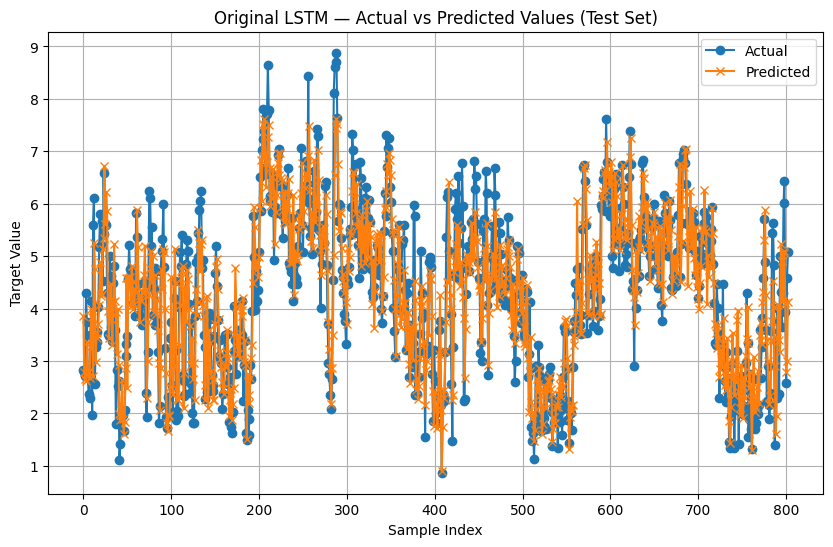

In [13]:
# =============================================================================
# SECTION 1 — ORIGINAL LSTM MODEL  (No Hyperparameter Optimisation)
# =============================================================================
## LSTM Original

# Build LSTM model
lstm_orig = Sequential()
lstm_orig.add(LSTM(50, activation='tanh', input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])))
lstm_orig.add(Dense(1))   # Output layer for regression

lstm_orig.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

# Train the model
history_orig = lstm_orig.fit(
    X_train_lstm, y_train_lstm,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    verbose=1,
    shuffle=False   # Critical for time series: do not shuffle
)

# Predict
y_train_pred_lstm = lstm_orig.predict(X_train_lstm).flatten()
y_test_pred_lstm  = lstm_orig.predict(X_test_lstm).flatten()

# Evaluate LSTM — store named metric variables for the final comparison table
print("\n--- LSTM Original Model Evaluation ---")
lstm_train_mse,  lstm_train_rmse,  lstm_train_mae,  lstm_train_mape,  lstm_train_r2  = \
    evaluate_metrics(y_train_lstm, y_train_pred_lstm, label="Train (LSTM)")
lstm_test_mse,   lstm_test_rmse,   lstm_test_mae,   lstm_test_mape,   lstm_test_r2   = \
    evaluate_metrics(y_test_lstm,  y_test_pred_lstm,  label="Test (LSTM)")

# Comparison dataframe
comparison_df = pd.DataFrame({
    'Actual':    y_test_lstm,
    'Predicted': y_test_pred_lstm
})
print(comparison_df.head(20))

# Plot results
plt.figure(figsize=(10, 6))
plt.plot(y_test_lstm,      label='Actual',    marker='o')
plt.plot(y_test_pred_lstm, label='Predicted', marker='x')
plt.title('Original LSTM — Actual vs Predicted Values (Test Set)')
plt.xlabel('Sample Index')
plt.ylabel('Target Value')
plt.legend()
plt.grid(True)
plt.show()

## Section 2 — Grid Search CV Hyperparameter Tuning
TimeSeriesSplit cross-validation applied on training data only.  
**Fix**: Original used `cv=3` (standard KFold) — for time series this allows future data into training folds (data leakage). Replaced with `TimeSeriesSplit(n_splits=5)`.

Fitting 5 folds for each of 72 candidates, totalling 360 fits
[CV] END batch_size=16, epochs=50, model__dropout_rate=0.1, model__optimizer=adam, model__units=32; total time=  19.4s
[CV] END batch_size=16, epochs=50, model__dropout_rate=0.1, model__optimizer=adam, model__units=32; total time=  11.9s
[CV] END batch_size=16, epochs=50, model__dropout_rate=0.1, model__optimizer=adam, model__units=32; total time=  16.5s
[CV] END batch_size=16, epochs=50, model__dropout_rate=0.1, model__optimizer=adam, model__units=32; total time=  21.2s
[CV] END batch_size=16, epochs=50, model__dropout_rate=0.1, model__optimizer=adam, model__units=32; total time=  24.3s
[CV] END batch_size=16, epochs=50, model__dropout_rate=0.1, model__optimizer=adam, model__units=64; total time=  11.5s
[CV] END batch_size=16, epochs=50, model__dropout_rate=0.1, model__optimizer=adam, model__units=64; total time=  11.4s
[CV] END batch_size=16, epochs=50, model__dropout_rate=0.1, model__optimizer=adam, model__units=64; total

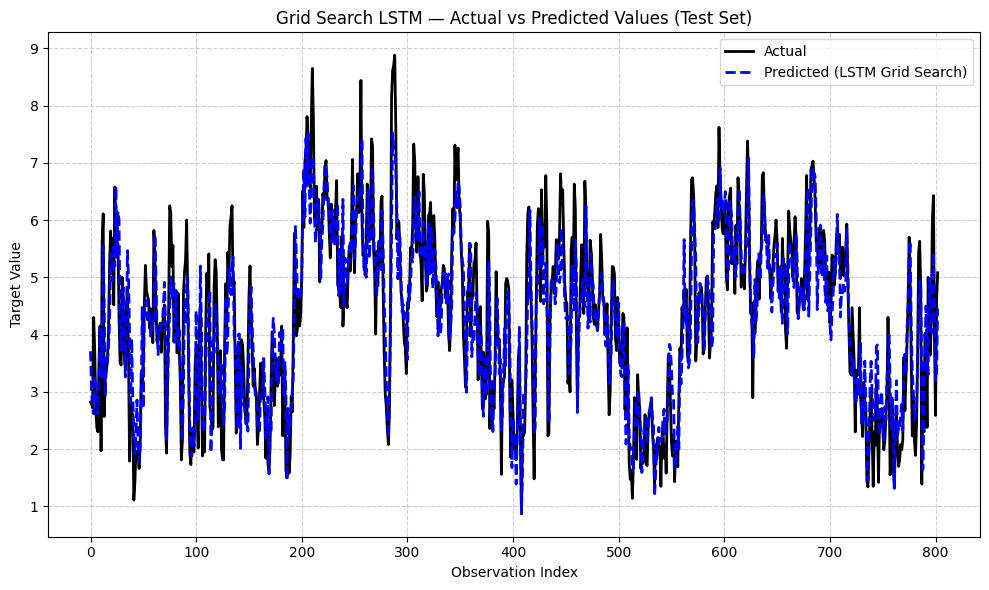

In [7]:
# =============================================================================
# SECTION 2 — GRID SEARCH CV  Hyperparameter Tuning
# FIX: Original used cv=3 (standard KFold). For a time series problem, standard
#      KFold randomly mixes future observations into training folds — data leakage.
#      Replaced with TimeSeriesSplit(n_splits=5) to ensure training always
#      precedes validation in time.
# TimeSeriesSplit cross-validation applied on training data only
# =============================================================================
## Grid Search

# Model builder function for KerasRegressor
def build_lstm_model(units=64, dropout_rate=0.2, optimizer='adam'):
    model = Sequential()
    model.add(LSTM(units, activation='tanh', return_sequences=False,
                   input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])))
    model.add(Dropout(dropout_rate))
    model.add(Dense(1))
    model.compile(optimizer=optimizer, loss='mse')
    return model

# Wrap with KerasRegressor
lstm_regressor_grid = KerasRegressor(model=build_lstm_model, verbose=0,
                                     random_state=RANDOM_SEED)

# Define parameter grid
param_grid = {
    "model__units":        [32, 64, 128],
    "model__dropout_rate": [0.1, 0.2, 0.3],
    "model__optimizer":    ['adam', 'rmsprop'],
    "batch_size":          [16, 32],
    "epochs":              [50, 100]
}

# TimeSeriesSplit ensures training always precedes validation in time
# FIX: replaced cv=3 (KFold) with TimeSeriesSplit to prevent data leakage
tscv = TimeSeriesSplit(n_splits=5)

# Grid Search — fitted on X_train_lstm only (no test set exposure)
grid_search = GridSearchCV(
    estimator=lstm_regressor_grid,
    param_grid=param_grid,
    scoring='neg_mean_squared_error',
    cv=tscv,
    verbose=2,
    n_jobs=1,      # Keep n_jobs=1 for TensorFlow thread safety
    refit=True     # Refit best model on full X_train_lstm automatically
)

# Fit grid search on training data only
grid_result = grid_search.fit(X_train_lstm, y_train_lstm)

# Best model
best_lstm_grid = grid_result.best_estimator_

print("\nBest Parameters Found (Grid Search):")
print(grid_result.best_params_)

# --- Optimal performance: predict on full X_train_lstm and X_test_lstm ---
y_train_pred_lstm_grid = best_lstm_grid.predict(X_train_lstm).flatten()
y_test_pred_lstm_grid  = best_lstm_grid.predict(X_test_lstm).flatten()

# Evaluate
print("\n--- LSTM Evaluation (Grid Search) ---")
grid_train_mse,  grid_train_rmse,  grid_train_mae,  grid_train_mape,  grid_train_r2  = \
    evaluate_metrics(y_train_lstm, y_train_pred_lstm_grid, label="Train (LSTM Grid Search)")
grid_test_mse,   grid_test_rmse,   grid_test_mae,   grid_test_mape,   grid_test_r2   = \
    evaluate_metrics(y_test_lstm,  y_test_pred_lstm_grid,  label="Test (LSTM Grid Search)")

# Plot
plt.figure(figsize=(10, 6))
plt.plot(y_test_lstm,             label='Actual',                     color='black', linewidth=2)
plt.plot(y_test_pred_lstm_grid,   label='Predicted (LSTM Grid Search)', color='blue', linestyle='--', linewidth=2)
plt.title('Grid Search LSTM — Actual vs Predicted Values (Test Set)')
plt.xlabel('Observation Index')
plt.ylabel('Target Value')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## Section 3 — Randomized Search CV Hyperparameter Tuning
TimeSeriesSplit cross-validation applied on training data only.  
**Fix**: Original used `cv=3` (standard KFold) — replaced with `TimeSeriesSplit(n_splits=5)`.

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END batch_size=54, epochs=101, model__dropout_rate=0.38521429192297485, model__learning_rate=0.006687945476302646, model__units=40; total time=   9.6s
[CV] END batch_size=54, epochs=101, model__dropout_rate=0.38521429192297485, model__learning_rate=0.006687945476302646, model__units=40; total time=  11.8s
[CV] END batch_size=54, epochs=101, model__dropout_rate=0.38521429192297485, model__learning_rate=0.006687945476302646, model__units=40; total time=  14.4s
[CV] END batch_size=54, epochs=101, model__dropout_rate=0.38521429192297485, model__learning_rate=0.006687945476302646, model__units=40; total time=  16.6s
[CV] END batch_size=54, epochs=101, model__dropout_rate=0.38521429192297485, model__learning_rate=0.006687945476302646, model__units=40; total time=  19.8s
[CV] END batch_size=54, epochs=132, model__dropout_rate=0.12999247474540088, model__learning_rate=0.004233240027692805, model__units=136; total time=  14.0s
[C

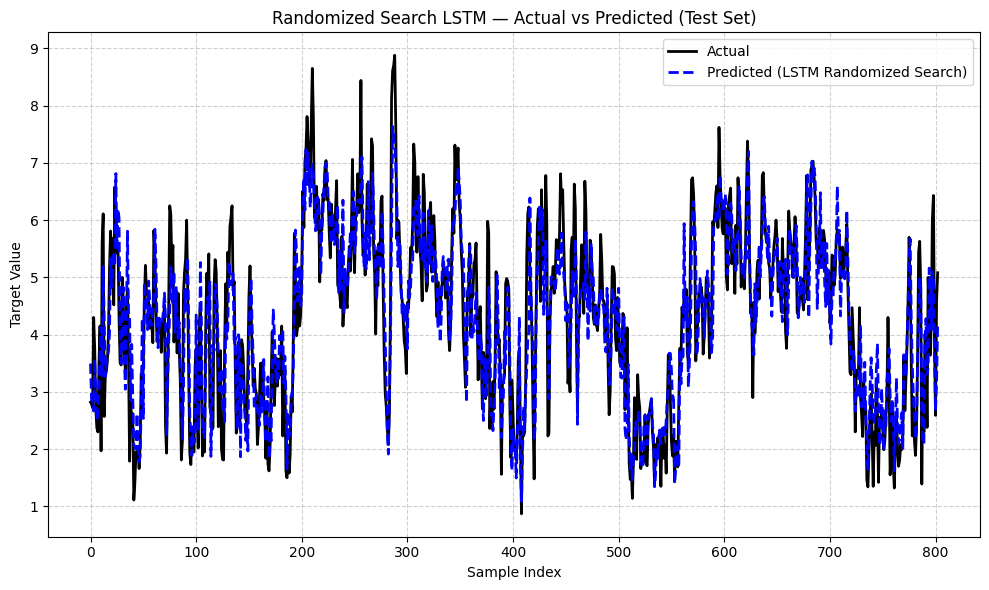

In [8]:
# =============================================================================
# SECTION 3 — RANDOMIZED SEARCH CV  Hyperparameter Tuning
# FIX: Original used cv=3 (standard KFold) — data leakage for time series.
#      Replaced with TimeSeriesSplit(n_splits=5).
# TimeSeriesSplit cross-validation applied on training data only
# =============================================================================
## Random Search

# Define function to create model (required for KerasRegressor)
def create_lstm_model(units=50, dropout_rate=0.2, learning_rate=0.001):
    model = Sequential()
    model.add(LSTM(units=units, input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])))
    model.add(Dropout(dropout_rate))
    model.add(Dense(1))   # Regression output
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(loss='mse', optimizer=optimizer)
    return model

# Wrap the model using scikeras
lstm_regressor_random = KerasRegressor(model=create_lstm_model, verbose=0,
                                       random_state=RANDOM_SEED)

# Define parameter distribution with correct scikeras syntax
param_dist = {
    'model__units':         randint(20, 151),
    'model__dropout_rate':  uniform(0.1, 0.3),
    'model__learning_rate': uniform(1e-4, 9e-3),
    'batch_size':           randint(16, 65),
    'epochs':               randint(50, 151)
}

# TimeSeriesSplit — applied on training data only
# FIX: replaced cv=3 (KFold) with TimeSeriesSplit to prevent data leakage
tscv = TimeSeriesSplit(n_splits=5)

# Setup RandomizedSearchCV — fitted on X_train_lstm only (no test set exposure)
random_search = RandomizedSearchCV(
    estimator=lstm_regressor_random,
    param_distributions=param_dist,
    n_iter=10,
    cv=tscv,
    random_state=RANDOM_SEED,
    verbose=2,
    n_jobs=1,     # Keep n_jobs=1 for TensorFlow thread safety
    refit=True    # Refit best model on full X_train_lstm automatically
)

# Fit RandomizedSearchCV on training data only
random_search.fit(X_train_lstm, y_train_lstm)

# Best params
print("Best Hyperparameters (Randomized Search):", random_search.best_params_)

# --- Optimal performance: predict on full X_train_lstm and X_test_lstm ---
y_train_pred_lstm_random = random_search.predict(X_train_lstm).flatten()
y_test_pred_lstm_random  = random_search.predict(X_test_lstm).flatten()

# Evaluation
print("\n--- LSTM Evaluation (Randomized Search) ---")
random_train_mse,  random_train_rmse,  random_train_mae,  random_train_mape,  random_train_r2  = \
    evaluate_metrics(y_train_lstm, y_train_pred_lstm_random, label="Train (LSTM Randomized Search)")
random_test_mse,   random_test_rmse,   random_test_mae,   random_test_mape,   random_test_r2   = \
    evaluate_metrics(y_test_lstm,  y_test_pred_lstm_random,  label="Test (LSTM Randomized Search)")

# Create a DataFrame to compare actual and predicted values on test set
comparison_df = pd.DataFrame({
    'Actual':    y_test_lstm,
    'Predicted': y_test_pred_lstm_random
})
print(comparison_df.head(20))

# Plot actual vs predicted for test set
plt.figure(figsize=(10, 6))
plt.plot(y_test_lstm,               label='Actual',                         color='black', linewidth=2)
plt.plot(y_test_pred_lstm_random,   label='Predicted (LSTM Randomized Search)', color='blue', linestyle='--', linewidth=2)
plt.title('Randomized Search LSTM — Actual vs Predicted (Test Set)')
plt.xlabel('Sample Index')
plt.ylabel('Target Value')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## Section 4 — Optuna Hyperparameter Tuning
TimeSeriesSplit cross-validation applied on training data only.  
**Fix 1**: `suggest_loguniform` deprecated — replaced with `suggest_float(..., log=True)`.  
**Fix 2**: `X_train_sub.shape[1]` in final refit was undefined (`NameError`) — replaced with `X_train.shape[1]`.  
**Fix 3**: Duplicate final model refit+evaluate block removed.

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


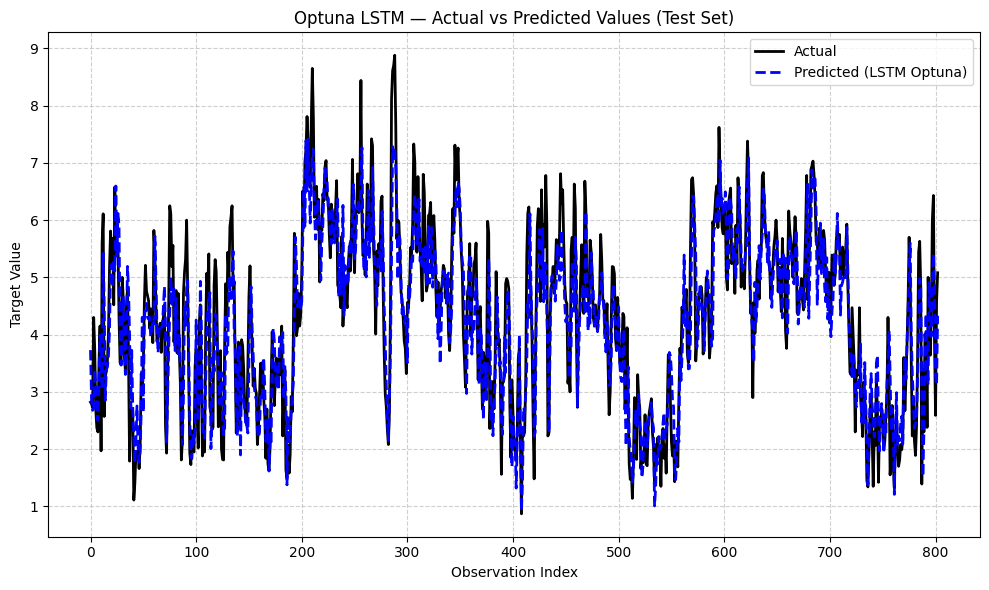

In [9]:
# =============================================================================
# SECTION 4 — OPTUNA  Hyperparameter Tuning
# FIX 1: suggest_loguniform is deprecated — replaced with suggest_float(..., log=True)
# FIX 2: final model used X_train_sub.shape[1] which is never defined in this
#         section — would crash with NameError. Replaced with X_train.shape[1].
# FIX 3: The final refit + evaluate + plot block was duplicated — removed duplicate.
# TimeSeriesSplit cross-validation applied on training data only
# =============================================================================
## Optuna

# Build LSTM model function for Optuna
def create_lstm_model_optuna(trial):
    units         = trial.suggest_int('units', 20, 150)
    dropout_rate  = trial.suggest_float('dropout_rate', 0.1, 0.5)
    # FIX: suggest_loguniform is deprecated — replaced with suggest_float(..., log=True)
    learning_rate = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)

    model = Sequential()
    model.add(LSTM(units=units, input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])))
    model.add(Dropout(dropout_rate))
    model.add(Dense(1))   # Regression output
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(loss='mse', optimizer=optimizer)
    return model

# Optuna objective for LSTM
def lstm_objective(trial):
    batch_size = trial.suggest_categorical('batch_size', [16, 32, 64])
    epochs     = trial.suggest_int('epochs', 50, 150)

    model = create_lstm_model_optuna(trial)

    # Use TimeSeriesSplit CV on X_train_lstm only — avoids any exposure to held-out X_test
    tscv_optuna = TimeSeriesSplit(n_splits=5)
    mse_scores  = []

    for fold_train_idx, fold_val_idx in tscv_optuna.split(X_train_lstm):
        X_fold_tr  = X_train_lstm[fold_train_idx]
        X_fold_val = X_train_lstm[fold_val_idx]
        y_fold_tr  = y_train_lstm[fold_train_idx]
        y_fold_val = y_train_lstm[fold_val_idx]

        model.fit(
            X_fold_tr, y_fold_tr,
            validation_data=(X_fold_val, y_fold_val),
            epochs=epochs,
            batch_size=batch_size,
            verbose=0,
            shuffle=False   # Critical for time series: do not shuffle
        )
        preds = model.predict(X_fold_val).flatten()
        # Return mean CV MSE across all folds — no test set exposure
        mse_scores.append(mean_squared_error(y_fold_val, preds))

    return np.mean(mse_scores)

# Create and run Optuna study
study = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED)
)
study.optimize(lstm_objective, n_trials=30, timeout=600)

print("\nBest Trial:")
print(study.best_trial)
print("\nBest Parameters:")
print(study.best_params)

# --- Optimal performance: refit final model on full X_train_lstm ---
# FIX: X_train_sub was undefined — now correctly uses X_train.shape[1]
# FIX: Duplicate refit block removed — model is built and evaluated only once here
best_params = study.best_params

final_lstm_optuna = Sequential()
final_lstm_optuna.add(LSTM(units=best_params['units'],
                           input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])))
final_lstm_optuna.add(Dropout(best_params['dropout_rate']))
final_lstm_optuna.add(Dense(1))
optimizer = Adam(learning_rate=best_params['learning_rate'])
final_lstm_optuna.compile(loss='mse', optimizer=optimizer)

final_lstm_optuna.fit(
    X_train_lstm, y_train_lstm,
    epochs=best_params['epochs'],
    batch_size=best_params['batch_size'],
    verbose=1,
    shuffle=False   # Critical for time series: do not shuffle
)

# Predict
y_train_pred_lstm_optuna = final_lstm_optuna.predict(X_train_lstm).flatten()
y_test_pred_lstm_optuna  = final_lstm_optuna.predict(X_test_lstm).flatten()

# Evaluate
print("\n--- Optimized LSTM Evaluation (Optuna) ---")
optuna_train_mse,  optuna_train_rmse,  optuna_train_mae,  optuna_train_mape,  optuna_train_r2  = \
    evaluate_metrics(y_train_lstm, y_train_pred_lstm_optuna, label="Train (LSTM Optuna)")
optuna_test_mse,   optuna_test_rmse,   optuna_test_mae,   optuna_test_mape,   optuna_test_r2   = \
    evaluate_metrics(y_test_lstm,  y_test_pred_lstm_optuna,  label="Test (LSTM Optuna)")

# Plot results
plt.figure(figsize=(10, 6))
plt.plot(y_test_lstm,                label='Actual',                       color='black', linewidth=2)
plt.plot(y_test_pred_lstm_optuna,    label='Predicted (LSTM Optuna)',       color='blue',  linestyle='--', linewidth=2)
plt.title('Optuna LSTM — Actual vs Predicted Values (Test Set)')
plt.xlabel('Observation Index')
plt.ylabel('Target Value')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## Final Comparison Table

In [10]:
# =============================================================================
# FINAL COMPARISON TABLE
# Optimal train/test performance for each method
# (best model refitted on full X_train_lstm, evaluated on held-out X_test_lstm)
# =============================================================================

# Create a DataFrame with the evaluation metrics for each model
data = {
    'Method':         ['Original Model', 'Grid Search', 'Randomized Search', 'Optuna'],

    'Train MSE':      [lstm_train_mse,   grid_train_mse,   random_train_mse,   optuna_train_mse],
    'Test MSE':       [lstm_test_mse,    grid_test_mse,    random_test_mse,    optuna_test_mse],

    'Train MAE':      [lstm_train_mae,   grid_train_mae,   random_train_mae,   optuna_train_mae],
    'Test MAE':       [lstm_test_mae,    grid_test_mae,    random_test_mae,    optuna_test_mae],

    'Train RMSE':     [lstm_train_rmse,  grid_train_rmse,  random_train_rmse,  optuna_train_rmse],
    'Test RMSE':      [lstm_test_rmse,   grid_test_rmse,   random_test_rmse,   optuna_test_rmse],

    'Train MAPE (%)': [lstm_train_mape,  grid_train_mape,  random_train_mape,  optuna_train_mape],
    'Test MAPE (%)':  [lstm_test_mape,   grid_test_mape,   random_test_mape,   optuna_test_mape],

    'Train R²':       [lstm_train_r2,    grid_train_r2,    random_train_r2,    optuna_train_r2],
    'Test R²':        [lstm_test_r2,     grid_test_r2,     random_test_r2,     optuna_test_r2],
}

# Convert the dictionary into a pandas DataFrame
metrics_df = pd.DataFrame(data)

# Print the title
print("\n" + "=" * 60)
print("   Variable Set 1 — LSTM Modelling")
print("   (Optimal Train/Test Performance per Method)")
print("=" * 60 + "\n")

# Display the table
print(metrics_df.to_string(index=False))

# Save the DataFrame to an Excel file
metrics_df.to_excel('VariableSet1_LSTM.xlsx', index=False)
print("\nResults saved to 'VariableSet1_LSTM.xlsx'")

NameError: name 'lstm_train_mse' is not defined